## The purpose of this experiment to answer these questions
- Can i predict the mask from any new H pose camera?
- Can i reveal the iddent state sigms?
- Can i reveal the depth map?

## Part 5 Train (neglict ci)

## import libraries

In [1]:

from __future__ import annotations
from pathlib import Path
from typing import List
import platform
import sys

import numpy as np
import torch
import matplotlib.pyplot as plt

# nerflab imports (make sure your env has nerflab on PYTHONPATH)
from nerflab import Intrinsics, Camera, CFG, load_world, plot_world
from nerflab.io import (load_frame_npz, load_batch, validate_loaded_batch,
                        discover_cfg_hash, list_frame_npz, frame_ids_from_paths, camera_from_loaded_H)
from nerflab.viz.render import Renderer, BinaryRenderCfg
from nerflab.viz.plot_nonzero_sigma import plot_nonzero_sigma_row
from nerflab.viz.viz_sigma import viz_sigma_heatmap, viz_sigma_scatter  # adjust import if needed



In [2]:
# gpu_check.py

print(f"PyTorch           : {torch.__version__}")
print(f"Python            : {platform.python_version()} ({sys.executable})")
print(f"CUDA available    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA toolkit ver. : {torch.version.cuda}")
    print(f"CuDNN ver.        : {torch.backends.cudnn.version()}")
    print(f"GPU count         : {torch.cuda.device_count()}")
    for idx in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(idx)
        print(f"  · Device {idx}: {props.name} "
              f"({props.total_memory/1024**3:.1f} GB, "
              f"Compute {props.major}.{props.minor})")
else:
    print("→  No CUDA GPU detected by PyTorch.")


PyTorch           : 2.7.1+cu128
Python            : 3.10.12 (/home/elyamani/Main/programming/nerf-lab/.venv/bin/python)
CUDA available    : True
CUDA toolkit ver. : 12.8
CuDNN ver.        : 90701
GPU count         : 1
  · Device 0: NVIDIA GeForce RTX 4050 Laptop GPU (5.6 GB, Compute 8.9)


In [3]:

# ---- Parameters (edit these) ----
scene_dir = Path("../data/data_experiment1")  # root scene directory
split = "train"                   # one of: "train", "val", "test"
seed = 7
cfg_hash = None                  # if None, auto-discover from cache folder
num_frames = 10
frame_offset = 20
device = "cpu"                   # set "cuda" if available
show_world = True               # set True to plot the world and selected camera
world_json_path = "../data/world.json"  # update if your world.json lives elsewhere


In [4]:

# ---- Discover cfg_hash and list NPZ frames ----
_cfg = cfg_hash or discover_cfg_hash(scene_dir, split)
npz_paths_all = list_frame_npz(scene_dir, _cfg, split)
if len(npz_paths_all) == 0:
    raise RuntimeError("No NPZ files found. Run the save demo first.")

npz_paths = npz_paths_all[frame_offset : frame_offset + num_frames]
frame_ids = frame_ids_from_paths(npz_paths)
print(f"Loading cfg_hash={_cfg}, split={split}, frames={frame_ids}")

# ---- Single-frame load (numpy mode) ----
npz0 = load_frame_npz(str(npz_paths[0]), as_torch=False)
print(f"Single frame: O shape={npz0['O'].shape}, C shape={npz0['C'].shape}, width={npz0['width']}, height={npz0['height']}")

# ---- Same frame in torch mode (device-aware) ----
t0 = load_frame_npz(str(npz_paths[0]), as_torch=True, device=torch.device(device))
assert torch.is_tensor(t0["O"]) and torch.is_tensor(t0["C"])

# ---- Batch load and validate ----
batch = load_batch(str(scene_dir), _cfg, split, frame_ids, seed=seed, as_torch=True, device=torch.device(device))
validate_loaded_batch(batch)
print(f"Batched: H_wc={tuple(batch['H_wc'].shape)}, O={tuple(batch['O'].shape)}, C={tuple(batch['C'].shape)}")


Loading cfg_hash=9867679e2750, split=train, frames=['000020', '000021', '000022', '000023', '000024', '000025', '000026', '000027', '000028', '000029']
Single frame: O shape=(307200, 3), C shape=(307200,), width=640, height=480
Batched: H_wc=(10, 4, 4), O=(10, 307200, 3), C=(10, 307200)


In [5]:
idx_render = 2                   # index (within loaded batch) for per-frame visualizations


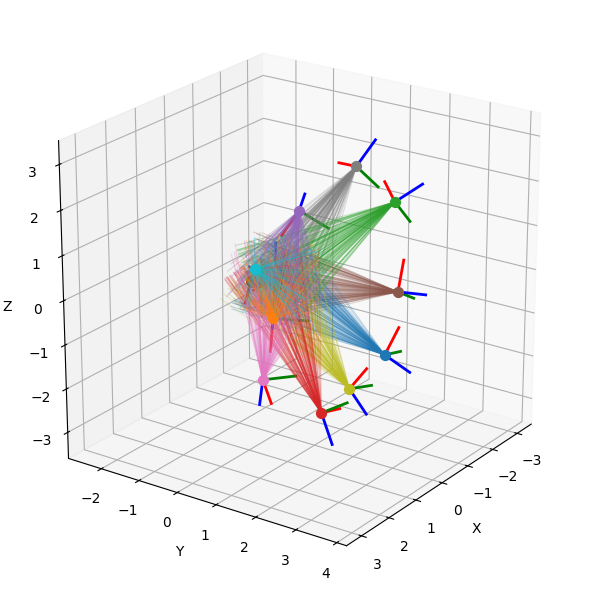

In [6]:

# ---- Optional: plot the world and selected camera ----
if show_world:
    try:
        world = load_world(world_json_path)
        cam = camera_from_loaded_H(batch["H_wc"])
        idx = max(0, min(idx_render, cam.B - 1))
        plot_world(
            world,
            cameras=cam,
            # cam_indices=[idx],
            cam_indices='all',
            draw_rays=True,
            ray_mode="lines",
            rays_per_pose=100,
            samples_deterministic=False,
            ray_alpha=0.25,
            samples_alpha=0.1,
            shape_edge_alpha=1.0,
            shape_face_alpha=0.6,
            set_labels=False,
        )
        plt.show()
    except Exception as e:
        print("World plot skipped due to error:", e)


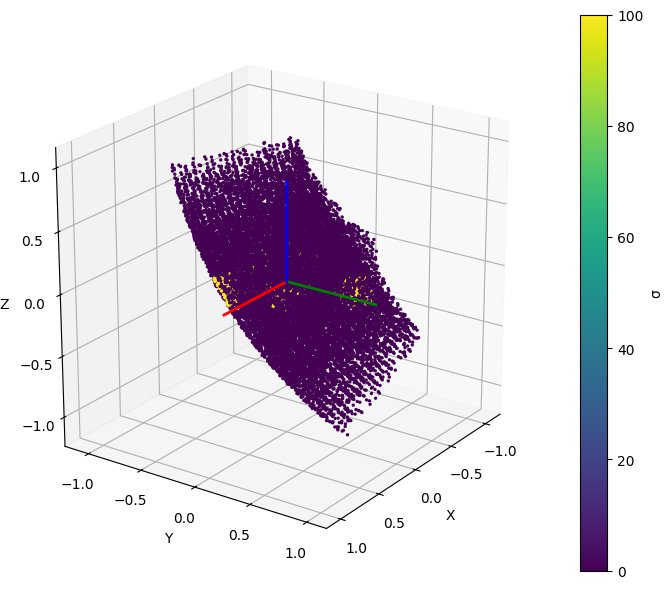

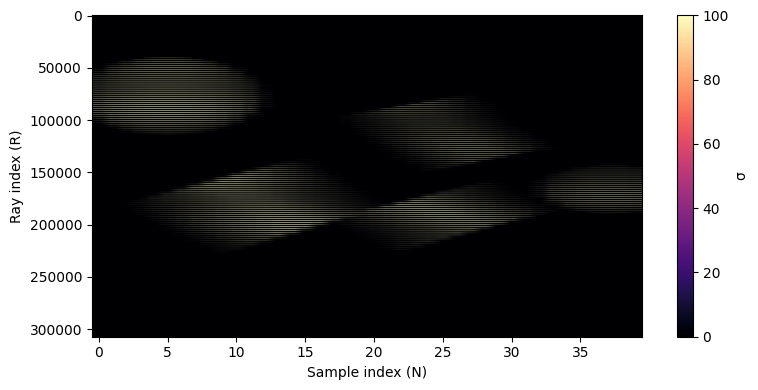

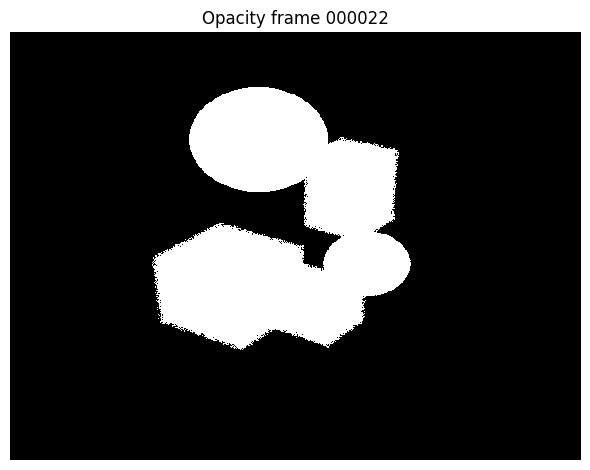

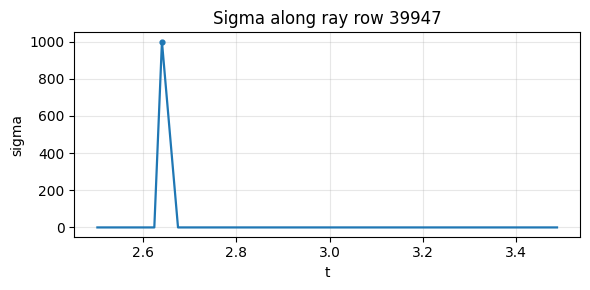

Picked row: 39947


In [7]:

# ---- Visualize sigma & opacity for a chosen frame ----
idx = max(0, min(idx_render, batch["C"].shape[0] - 1))
H, W = int(batch["height"]), int(batch["width"])

# Per-frame arrays (Torch tensors)
t = batch["t"][idx]          # (R, N)
sigma = batch["sigma"][idx]  # (R, N)
C = batch["C"][idx]          # (R,)

# Convert to numpy for viz helpers
t_np = t.detach().cpu().numpy()
sigma_np = sigma.detach().cpu().numpy()

# Downsample for scatter to keep it light
R = H * W
N = t_np.shape[-1]
stride_r = max(1, R // 5000)   # adjust if you want fewer/more points
stride_n = max(1, N // 16)

# Optional 3D scatter if X present
if "X" in batch:
    X = batch["X"][idx]  # (R, N, 3)
    if X.ndim == 3 and X.shape[-1] == 3 and X.shape[:2] == sigma.shape:
        X_np = X.detach().cpu().numpy()
        X_sub = X_np[::stride_r, ::stride_n, :]      # (R', N', 3)
        sigma_sub = sigma_np[::stride_r, ::stride_n] # (R', N')
        viz_sigma_scatter(X_sub, sigma_sub)          # no flattening
        plt.show()
    else:
        print("Skipping scatter: X shape is not (R,N,3) matching sigma (R,N).")
else:
    print("Skipping scatter: batch does not contain 'X' (store_points=False when saving).")

# Heatmap over sigma (expects (R, N))
viz_sigma_heatmap(sigma_np)
plt.show()

# Opacity mask render
rnd = Renderer(BinaryRenderCfg(threshold=0.5))
fig, ax, _ = rnd.binary(
    C.reshape(H, W).detach().cpu().numpy(),
    intr=Intrinsics(**CFG.intrinsics.__dict__),
    title=f"Opacity frame {frame_ids[idx]}",
    save_path=str(scene_dir / f"opacity_{frame_ids[idx]}.png"),
)
plt.show()

# Example: pick a nonzero sigma row to inspect
r = plot_nonzero_sigma_row(t, sigma, strategy="max", mark_nonzero=True)
print(f"Picked row: {r}")
